<a href="https://colab.research.google.com/github/kml19dotcom/lecture1/blob/main/pum5_regresjanieliniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [2]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_28278/2150386848.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 18.9k/18.9k [00:00<00:00, 27.0MB/s]

First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [3]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

In [4]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [10]:
regressor = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressor.coef_}")
print(f"Wyraz wolny: {regressor.intercept_}")
print(f" R^2 {regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny z treningu: {mean_absolute_error(y_train, regressor.predict(X_train)):.2f}")

y_pred = regressor.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred):.2f}")

Współczynniki: [ 5943.1165944  14230.65620481    45.79250736  5841.35149661]
Wyraz wolny: 27035.26747556431
 R^2 0.894454987884499
Średni błąd absolutny z treningu: 11367.70
Średni błąd kwadratowy: 240128620.02
Średni błąd absolutny: 11005.92
Wyjaśniona wariancja: 0.89


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF




In [9]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop(columns=['Salary', 'Age'])  #VIF > 10

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Spróbuj poprawić wynik używając regresji LASSO

In [11]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = Lasso(alpha=100, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lasso.coef_
})
print(coef_df)

y_pred_lasso = lasso.predict(X_test_scaled)
print(f"\nR²:  {r2_score(y_test, y_pred_lasso):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lasso):.2f}")

for alpha in [100, 1000, 5000, 10000]:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    zeroed = (lasso.coef_ == 0).sum()
    print(f"alpha={alpha:6} | R²: {r2_score(y_test, y_pred):.4f} | MAE: {mean_absolute_error(y_test, y_pred):.2f} | Wyzerowane zmienne: {zeroed}")



               feature   coefficient
0               Gender   2877.043301
1      Education Level  10096.586954
2            Job Title   2114.689035
3  Years of Experience  38268.984638

R²:  0.8937
MAE: 11016.56
MSE: 240154596.07
alpha=   100 | R²: 0.8937 | MAE: 11016.56 | Wyzerowane zmienne: 0
alpha=  1000 | R²: 0.8926 | MAE: 11190.14 | Wyzerowane zmienne: 0
alpha=  5000 | R²: 0.8766 | MAE: 12535.58 | Wyzerowane zmienne: 2
alpha= 10000 | R²: 0.8414 | MAE: 14811.83 | Wyzerowane zmienne: 2


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję





In [12]:
# Dodanie zmiennej - kwadrat lat doświadczenia
X_train = X_train.copy()
X_test = X_test.copy()
X_train['Experience²'] = X_train['Years of Experience'] ** 2
X_test['Experience²'] = X_test['Years of Experience'] ** 2

# Regresja z nową zmienną
regressor_poly = LinearRegression().fit(X_train, y_train)
y_pred_poly = regressor_poly.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred_poly):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_poly):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_poly):.2f}")

R²:  0.8932
MAE: 10749.87
MSE: 241271496.28


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

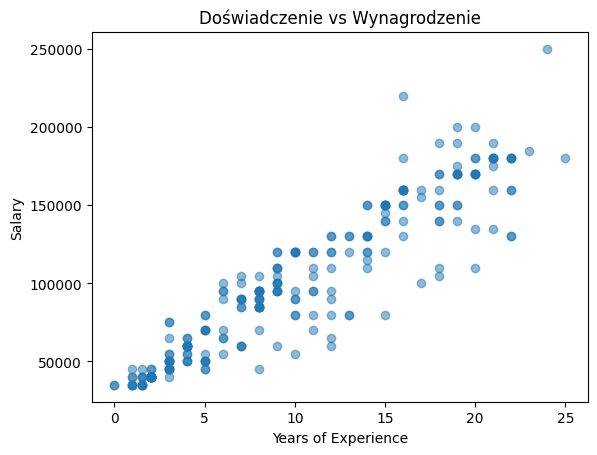

In [13]:
plt.scatter(X_train['Years of Experience'], y_train, alpha=0.5)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Doświadczenie vs Wynagrodzenie')
plt.show()

Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

regresja wielomianowa stopnia 2 i 3

In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

for degree in [2, 3]:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ])
    model.fit(X_train, y_train)
    y_pred_poly = model.predict(X_test)

    print(f"Stopień {degree} | R²: {r2_score(y_test, y_pred_poly):.4f} | MAE: {mean_absolute_error(y_test, y_pred_poly):.2f} | MSE: {mean_squared_error(y_test, y_pred_poly):.2f}")

Stopień 2 | R²: 0.8878 | MAE: 11085.29 | MSE: 253423010.73
Stopień 3 | R²: 0.8912 | MAE: 10929.26 | MSE: 245804306.47


regresja k-nn

In [15]:
from sklearn.neighbors import KNeighborsRegressor

for k in [3, 5, 10]:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)

    print(f"K={k:2} | R²: {r2_score(y_test, y_pred_knn):.4f} | MAE: {mean_absolute_error(y_test, y_pred_knn):.2f} | MSE: {mean_squared_error(y_test, y_pred_knn):.2f}")

K= 3 | R²: 0.8774 | MAE: 11663.54 | MSE: 276954466.77
K= 5 | R²: 0.8763 | MAE: 11702.23 | MSE: 279361808.04
K=10 | R²: 0.8719 | MAE: 12099.55 | MSE: 289237254.46


porównanie wyników

In [16]:
print("=" * 75)
print(f"{'Model':<25} {'R²':>8} {'MAE':>12} {'MSE':>20}")
print("=" * 75)
print(f"{'Benchmark (z Age)':<25} {0.9043:>8.4f} {11377.18:>12.2f} {252493731.92:>20.2f}")
print(f"{'Benchmark (bez Age)':<25} {0.8944:>8.4f} {11005.92:>12.2f} {240128620.02:>20.2f}")
print(f"{'LASSO (bez Age)':<25} {0.8937:>8.4f} {11016.56:>12.2f} {240154596.07:>20.2f}")
print(f"{'Experience²':<25} {0.8932:>8.4f} {10749.87:>12.2f} {241271496.28:>20.2f}")
print(f"{'Wielomianowa st. 2':<25} {0.8878:>8.4f} {11085.29:>12.2f} {253423010.73:>20.2f}")
print(f"{'Wielomianowa st. 3':<25} {0.8912:>8.4f} {10929.26:>12.2f} {245804306.47:>20.2f}")
print(f"{'K-NN (k=3)':<25} {0.8774:>8.4f} {11663.54:>12.2f} {276954466.77:>20.2f}")
print(f"{'K-NN (k=5)':<25} {0.8763:>8.4f} {11702.23:>12.2f} {279361808.04:>20.2f}")
print(f"{'K-NN (k=10)':<25} {0.8719:>8.4f} {12099.55:>12.2f} {289237254.46:>20.2f}")
print("=" * 75)

Model                           R²          MAE                  MSE
Benchmark (z Age)           0.9043     11377.18         252493731.92
Benchmark (bez Age)         0.8944     11005.92         240128620.02
LASSO (bez Age)             0.8937     11016.56         240154596.07
Experience²                 0.8932     10749.87         241271496.28
Wielomianowa st. 2          0.8878     11085.29         253423010.73
Wielomianowa st. 3          0.8912     10929.26         245804306.47
K-NN (k=3)                  0.8774     11663.54         276954466.77
K-NN (k=5)                  0.8763     11702.23         279361808.04
K-NN (k=10)                 0.8719     12099.55         289237254.46
